In [1]:
import pandas as pd

results = pd.read_csv('results.csv', index_col=0, sep=',')

In [2]:
results

,Experiment,Run,E,Ec,max(p)
Index,,,,,
1,1,1,138,NaN,6
2,1,2,130,NaN,4
3,1,3,140,NaN,3
4,1,4,137,NaN,9
5,1,5,141,NaN,9
6,1,6,131,NaN,9
7,2,1,148,150.0,9
8,2,2,152,154.0,6
9,2,3,160,154.0,9


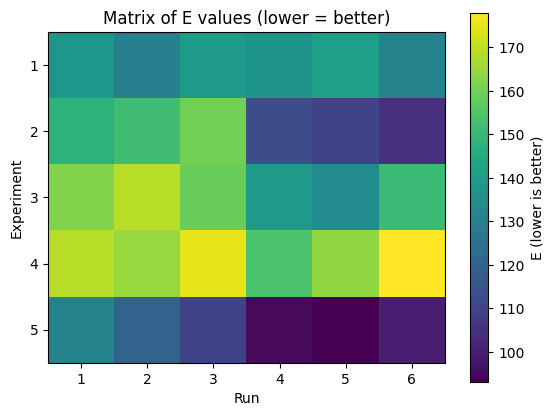

In [7]:

import matplotlib.pyplot as plt


matrix = results.pivot(index="Experiment", columns="Run", values="E")

plt.imshow(matrix)
plt.colorbar(label="E (lower is better)")
plt.xticks(range(len(matrix.columns)), matrix.columns)
plt.yticks(range(len(matrix.index)), matrix.index)

plt.xlabel("Run")
plt.ylabel("Experiment")
plt.title("Matrix of E values (lower = better)")

plt.show()

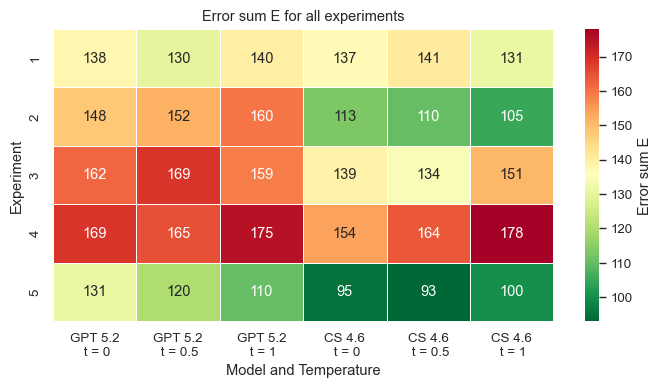

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = results.copy()

# Run sicher als int
df["Run"] = pd.to_numeric(df["Run"], errors="coerce").astype("Int64")

run_map = {
    1: ("GPT 5.2", 0),
    2: ("GPT 5.2", 0.5),
    3: ("GPT 5.2", 1),
    4: ("CS 4.6", 0),
    5: ("CS 4.6", 0.5),
    6: ("CS 4.6", 1),
}

mapped = df["Run"].map(run_map)
df["Model"] = mapped.str[0]
df["Temp"] = mapped.str[1]

# Label sauber formatieren (damit 0.0 -> 0)
def fmt_temp(t):
    if pd.isna(t):
        return None
    return str(int(t)) if float(t).is_integer() else str(t)

df["Label"] = df["Model"] + "\n t = " + df["Temp"].map(fmt_temp)

order = [
    "GPT 5.2\n t = 0",
    "GPT 5.2\n t = 0.5",
    "GPT 5.2\n t = 1",
    "CS 4.6\n t = 0",
    "CS 4.6\n t = 0.5",
    "CS 4.6\n t = 1",
]
matrix = (
    df.pivot(index="Experiment", columns="Label", values="E")
      .reindex(columns=order)   # <- statt [order]
      .sort_index()
)

sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.figure(figsize=(7, 4))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Error sum E"},
)

plt.title("Error sum E for all experiments")
plt.xlabel("Model and Temperature")
plt.ylabel("Experiment")
plt.tight_layout()
plt.savefig("E.png", dpi=600, bbox_inches="tight")
plt.savefig("E.pdf", bbox_inches="tight")
plt.show()

In [27]:
df

,Experiment,Run,E,Ec,max(p),Model,Temp,Label
Index,,,,,,,,
1,1,1,138,NaN,6,GPT 5.2,0.0,GPT 5.2\n t = 0
2,1,2,130,NaN,4,GPT 5.2,0.5,GPT 5.2\n t = 0.5
3,1,3,140,NaN,3,GPT 5.2,1.0,GPT 5.2\n t = 1
4,1,4,137,NaN,9,CS 4.6,0.0,CS 4.6\n t = 0
5,1,5,141,NaN,9,CS 4.6,0.5,CS 4.6\n t = 0.5
6,1,6,131,NaN,9,CS 4.6,1.0,CS 4.6\n t = 1
7,2,1,148,150.0,9,GPT 5.2,0.0,GPT 5.2\n t = 0
8,2,2,152,154.0,6,GPT 5.2,0.5,GPT 5.2\n t = 0.5
9,2,3,160,154.0,9,GPT 5.2,1.0,GPT 5.2\n t = 1


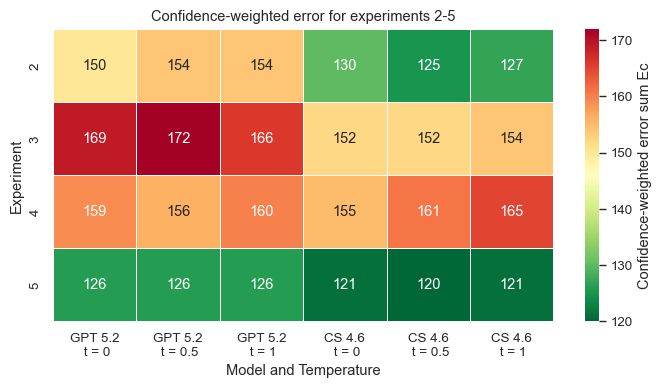

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = results.copy()
df = df[df["Experiment"].isin([2, 3, 4, 5])]

df["Run"] = pd.to_numeric(df["Run"], errors="coerce").astype("Int64")

run_map = {
    1: ("GPT 5.2", 0),
    2: ("GPT 5.2", 0.5),
    3: ("GPT 5.2", 1),
    4: ("CS 4.6", 0),
    5: ("CS 4.6", 0.5),
    6: ("CS 4.6", 1),
}

mapped = df["Run"].map(run_map)
df["Model"] = mapped.str[0]
df["Temp"] = mapped.str[1]

def fmt_temp(t):
    if pd.isna(t):
        return None
    return str(int(t)) if float(t).is_integer() else str(t)

df["Label"] = df["Model"] + "\n t = " + df["Temp"].map(fmt_temp)

order = [
    "GPT 5.2\n t = 0",
    "GPT 5.2\n t = 0.5",
    "GPT 5.2\n t = 1",
    "CS 4.6\n t = 0",
    "CS 4.6\n t = 0.5",
    "CS 4.6\n t = 1",
]
matrix = (
    df.pivot(index="Experiment", columns="Label", values="Ec")
      .reindex(columns=order)   # <- statt [order]
      .sort_index()
)

sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.figure(figsize=(7, 4))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Confidence-weighted error sum Ec"},
)

plt.title("Confidence-weighted error for experiments 2-5")
plt.xlabel("Model and Temperature")
plt.ylabel("Experiment")
plt.tight_layout()
plt.savefig("Ec.png", dpi=600, bbox_inches="tight")
plt.savefig("Ec.pdf", bbox_inches="tight")
plt.show()

/Users/s.franke/Development/Transcription/.venv/master_clean/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/s.franke/Development/Transcription/.venv/master_clean/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


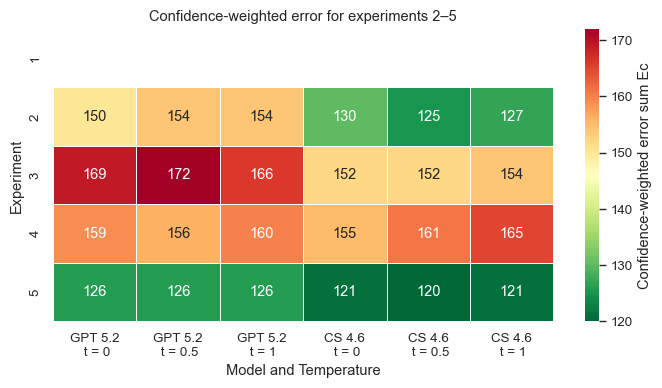

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = results.copy()


df["Run"] = pd.to_numeric(df["Run"], errors="coerce").astype("Int64")


run_map = {
    1: ("GPT 5.2", 0),
    2: ("GPT 5.2", 0.5),
    3: ("GPT 5.2", 1),
    4: ("CS 4.6", 0),
    5: ("CS 4.6", 0.5),
    6: ("CS 4.6", 1),
}

mapped = df["Run"].map(run_map)
df["Model"] = mapped.str[0]
df["Temp"] = mapped.str[1]

# --- Temp-Format (0.0 -> 0) ---
def fmt_temp(t):
    if pd.isna(t):
        return None
    return str(int(t)) if float(t).is_integer() else str(t)

# --- X-Achsenlabel: Model in Zeile 1, t in Zeile 2 ---
df["Label"] = df["Model"] + "\n t = " + df["Temp"].map(fmt_temp)

order = [
    "GPT 5.2\n t = 0",
    "GPT 5.2\n t = 0.5",
    "GPT 5.2\n t = 1",
    "CS 4.6\n t = 0",
    "CS 4.6\n t = 0.5",
    "CS 4.6\n t = 1",
]

# --- Matrix bauen: Experimente 1..5 beibehalten (1 ggf. als NaN placeholder) ---
matrix = (
    df.pivot(index="Experiment", columns="Label", values="Ec")
      .reindex(index=[1, 2, 3, 4, 5])     # Experiment 1 bleibt als Zeile drin
      .reindex(columns=order)             # feste Spaltenreihenfolge
)

# --- Mask für fehlende Werte (Experiment 1 wird dadurch grau) ---
mask = matrix.isna()

sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.figure(figsize=(7, 4))

# 1) Heatmap für vorhandene Werte
sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    mask=mask,
    cbar_kws={"label": "Confidence-weighted error sum Ec"},
)

# 2) Overlay: fehlende Werte grau darstellen
sns.heatmap(
    matrix,
    mask=~mask,
    cmap=["lightgrey"],
    cbar=False,
    linewidths=0.5,
)

plt.title("Confidence-weighted error for experiments 2–5")
plt.xlabel("Model and Temperature")
plt.ylabel("Experiment")

plt.tight_layout()
plt.savefig("Ec.png", dpi=600, bbox_inches="tight")
plt.savefig("Ec.pdf", bbox_inches="tight")
plt.show()

/var/folders/9k/bqn5d5t90kl0x7z66fx4d0cw0000gn/T/ipykernel_25005/3931264340.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r").copy()


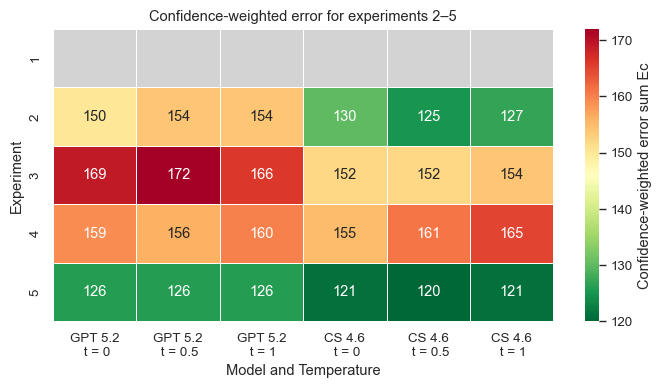

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = results.copy()

# --- Runs sicher als int ---
df["Run"] = pd.to_numeric(df["Run"], errors="coerce").astype("Int64")

# --- Run -> (Model, Temp) Mapping ---
run_map = {
    1: ("GPT 5.2", 0),
    2: ("GPT 5.2", 0.5),
    3: ("GPT 5.2", 1),
    4: ("CS 4.6", 0),
    5: ("CS 4.6", 0.5),
    6: ("CS 4.6", 1),
}

mapped = df["Run"].map(run_map)
df["Model"] = mapped.str[0]
df["Temp"] = mapped.str[1]

def fmt_temp(t):
    if pd.isna(t):
        return None
    return str(int(t)) if float(t).is_integer() else str(t)

# --- X-Achsen Label ---
df["Label"] = df["Model"] + "\n t = " + df["Temp"].map(fmt_temp)

order = [
    "GPT 5.2\n t = 0",
    "GPT 5.2\n t = 0.5",
    "GPT 5.2\n t = 1",
    "CS 4.6\n t = 0",
    "CS 4.6\n t = 0.5",
    "CS 4.6\n t = 1",
]

# --- Matrix bauen (Exp 1 bleibt placeholder) ---
matrix = (
    df.pivot(index="Experiment", columns="Label", values="Ec")
      .reindex(index=[1,2,3,4,5])
      .reindex(columns=order)
)

# --- Colormap mit grauen NaN ---
cmap = plt.cm.get_cmap("RdYlGn_r").copy()
cmap.set_bad("lightgrey")

sns.set_theme(style="white", context="paper", font_scale=1.1)

plt.figure(figsize=(7,4))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap=cmap,
    linewidths=0.5,
    cbar_kws={"label": "Confidence-weighted error sum Ec"},
)

plt.title("Confidence-weighted error for experiments 2–5")
plt.xlabel("Model and Temperature")
plt.ylabel("Experiment")

plt.tight_layout()

plt.savefig("Ec.png", dpi=600, bbox_inches="tight")
plt.savefig("Ec.pdf", bbox_inches="tight")

plt.show()

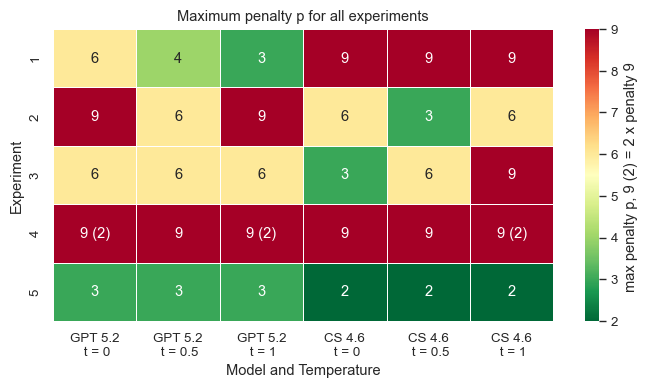

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = results.copy()

# 1) Run sicher int
df["Run"] = pd.to_numeric(df["Run"], errors="coerce").astype("Int64")

# 2) Model/Temp Mapping
run_map = {
    1: ("GPT 5.2", 0),
    2: ("GPT 5.2", 0.5),
    3: ("GPT 5.2", 1),
    4: ("CS 4.6", 0),
    5: ("CS 4.6", 0.5),
    6: ("CS 4.6", 1),
}
mapped = df["Run"].map(run_map)
df["Model"] = mapped.str[0]
df["Temp"] = mapped.str[1]

def fmt_temp(t):
    if pd.isna(t):
        return None
    return str(int(t)) if float(t).is_integer() else str(t)

# 3) X-Achsen-Label (separat!)
df["x_label"] = df["Model"] + "\n t = " + df["Temp"].map(fmt_temp)

order = [
    "GPT 5.2\n t = 0",
    "GPT 5.2\n t = 0.5",
    "GPT 5.2\n t = 1",
    "CS 4.6\n t = 0",
    "CS 4.6\n t = 0.5",
    "CS 4.6\n t = 1",
]

# 4) max(p) Labels setzen (separat!)
max_p_label = [
    "6", "4", "3",
    "9", "9", "9", "9",
    "6",
    "9",
    "6",
    "3",
    "6", "6", "6", "6",
    "3",
    "6",
    "9",
    "9 (2)", "9", "9 (2)", "9", "9", "9 (2)",
    "3", "3", "3",
    "2", "2", "2"
]
df["max_p_label"] = max_p_label

# 5) Numerischen Wert für Farbe erzeugen
# Wenn du KEINE numerische Spalte hast, ziehe die Zahl aus max_p_label:
df["max_p_num"] = pd.to_numeric(df["max_p_label"].str.extract(r"(\d+)")[0], errors="coerce")

# 6) Matrizen bauen
value_matrix = (
    df.pivot(index="Experiment", columns="x_label", values="max_p_num")
      .reindex(columns=order)
      .sort_index()
)
label_matrix = (
    df.pivot(index="Experiment", columns="x_label", values="max_p_label")
      .reindex(columns=order)
      .sort_index()
)

# 7) Plot
sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.figure(figsize=(7, 4))

sns.heatmap(
    value_matrix,
    annot=label_matrix,   # <-- Text-Labels (9(2))
    fmt="",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "max penalty p, 9 (2) = 2 x penalty 9 "},
)

plt.title("Maximum penalty p for all experiments")
plt.xlabel("Model and Temperature")
plt.ylabel("Experiment")
plt.tight_layout()
plt.savefig("maxP.png", dpi=600, bbox_inches="tight")
plt.savefig("maxP.pdf", bbox_inches="tight")
plt.show()

Auswertung gesamt

In [25]:
df = results

In [27]:
mean_run = (
    df.groupby(["Experiment", "Run"])
      .agg(
          mean_E=("E", "mean"),
          mean_Ec=("Ec", "mean"),
          max_penalty=("max(p)", "mean")
      )
      .reset_index()
)

print(mean_run)

    Experiment  Run  mean_E  mean_Ec  max_penalty
0            1    1   138.0      NaN          6.0
1            1    2   130.0      NaN          4.0
2            1    3   140.0      NaN          3.0
3            1    4   137.0      NaN          9.0
4            1    5   141.0      NaN          9.0
5            1    6   131.0      NaN          9.0
6            2    1   148.0    150.0          9.0
7            2    2   152.0    154.0          6.0
8            2    3   160.0    154.0          9.0
9            2    4   113.0    130.0          6.0
10           2    5   110.0    125.0          3.0
11           2    6   105.0    127.0          6.0
12           3    1   162.0    169.0          6.0
13           3    2   169.0    172.0          6.0
14           3    3   159.0    166.0          6.0
15           3    4   139.0    152.0          3.0
16           3    5   134.0    152.0          6.0
17           3    6   151.0    154.0          9.0
18           4    1   169.0    159.0          9.0


In [28]:
mean_experiment = (
    df.groupby("Experiment")
      .agg(
          mean_E=("E", "mean"),
          mean_Ec=("Ec", "mean"),
          std_E=("E", "std"),
          runs=("Run", "count")
      )
      .reset_index()
)

print(mean_experiment)

   Experiment      mean_E     mean_Ec      std_E  runs
0           1  136.166667         NaN   4.622409     6
1           2  131.333333  140.000000  24.541122     6
2           3  152.333333  160.833333  13.647955     6
3           4  167.500000  159.333333   8.596511     6
4           5  108.166667  123.333333  15.065413     6


In [29]:
pivot_E = df.pivot_table(
    values="E",
    index="Experiment",
    columns="Run",
    aggfunc="mean"
)

print(pivot_E)

Run             1      2      3      4      5      6
Experiment                                          
1           138.0  130.0  140.0  137.0  141.0  131.0
2           148.0  152.0  160.0  113.0  110.0  105.0
3           162.0  169.0  159.0  139.0  134.0  151.0
4           169.0  165.0  175.0  154.0  164.0  178.0
5           131.0  120.0  110.0   95.0   93.0  100.0


In [34]:
df = pd.read_csv('results.csv', index_col=0, sep=',')

In [35]:
run_map = {
    1: ("GPT 5.2", 0.0),
    2: ("GPT 5.2", 0.5),
    3: ("GPT 5.2", 1.0),
    4: ("Claude Sonnet 4.6", 0.0),
    5: ("Claude Sonnet 4.6", 0.5),
    6: ("Claude Sonnet 4.6", 1.0),
}

df["Model"] = df["Run"].map(lambda x: run_map[x][0])
df["Temp"] = df["Run"].map(lambda x: run_map[x][1])

model_perf = (
    df.groupby(["Model", "Temp"])
      .agg(
          mean_E=("E", "mean"),
          std_E=("E", "std"),
          mean_Ec=("Ec", "mean"),
          runs=("Run", "count")
      )
      .reset_index()
      .sort_values("mean_E")
)

print(model_perf)

               Model  Temp  mean_E      std_E  mean_Ec  runs
0  Claude Sonnet 4.6   0.0   127.6  23.405128   139.50     5
1  Claude Sonnet 4.6   0.5   128.4  27.609781   139.50     5
2  Claude Sonnet 4.6   1.0   133.0  32.503846   141.75     5
4            GPT 5.2   0.5   147.2  21.510463   152.00     5
5            GPT 5.2   1.0   148.8  24.993999   151.50     5
3            GPT 5.2   0.0   149.6  15.915401   151.00     5


In [31]:
df

,Experiment,Run,E,Ec,max(p),Model,Temp
Index,,,,,,,
1,1,1,138,NaN,6,GPT 5.2,0.0
2,1,2,130,NaN,4,GPT 5.2,0.0
3,1,3,140,NaN,3,GPT 5.2,0.0
4,1,4,137,NaN,9,GPT 5.2,0.0
5,1,5,141,NaN,9,GPT 5.2,0.0
6,1,6,131,NaN,9,GPT 5.2,0.0
7,2,1,148,150.0,9,GPT 5.2,0.5
8,2,2,152,154.0,6,GPT 5.2,0.5
9,2,3,160,154.0,9,GPT 5.2,0.5
